# Prompting Gemini 2
## Ejemplos de aplicaciones y casos reales de uso

Esta segunda guía se centra en poner en práctica Gemini para resolver tareas reales de procesamiento de lenguaje natural. 


## Tabla de contenido
- [Ejemplos de aplicaciones y casos reales de uso](#Ejemplos-de-aplicaciones-y-casos-reales-de-uso)
    - [Extracción de resúmenes usando Gemini](#Extracción-de-resúmenes-usando-Gemini)
    - [Evaluación de resúmenes usando Gemini](#Evaluación-de-resúmenes-usando-Gemini)
    - [Uso de Batch Predict para crear resúmenes usando Gemini](#Uso-de-Batch-Predict-para-crear-resúmenes-usando-Gemini)
    - [Extracción de categorías usando Gemini](#Extracción-de-categorías-usando-Gemini)
    - [Análisis de las categorías extraídas](#Análisis-de-las-categorías-extraídas)
    - [Evaluación de categorías](#Evaluación-de-categorías)
    - [Clasificación temática con categorías predefinidas](#Clasificación-temática-con-categorías-predefinidas)
    - [Extracción de satisfaccion usando Gemini](#Extracción-de-satisfaccion-usando-Gemini)
    - [Evaluación de satisfaccion](#Evaluación-de-satisfaccion)
- [Ejemplos adicionales](#Ejemplos-adicionales)
    - [Iniciar un chat de varios turnos](#Iniciar-un-chat-de-varios-turnos)
    - [Análisis de las categorías extraídas con Word Embeddings y Cosine Similarity](#Análisis-de-las-categorías-extraídas-con-Word-Embeddings-y-Cosine-Similarity)
    - [Visualización de word embeddings usando UMAP](#Visualización-de-word-embeddings-usando-UMAP)
    - [Extracción de entidades de documentos usando Gemini](#Extracción-de-entidades-de-documentos-usando-Gemini)

Importamos las librerías necesarias

In [32]:
import re
import os
import pandas as pd
import numpy as np
import json
import time
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
#import openpyxl
import mimetypes
import matplotlib as mpl
from matplotlib import patheffects as pe
from difflib import SequenceMatcher 
import io

from google import genai
from sklearn.metrics.pairwise import cosine_similarity
from google.cloud import storage
from google.genai.types import GenerateContentConfig, ThinkingConfig, SafetySetting, CreateBatchJobConfig, JobState, HttpOptions, EmbedContentConfig
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from wordcloud import WordCloud
from pydantic import BaseModel

from google.genai import types

Inicializar variables

In [ ]:
GEMINI_API_KEY=''
MODEL_ID = "gemini-3-flash-preview"

In [34]:
# Cargar datos
df = pd.read_csv("Big_AHR.csv", sep=',')
df.head()

,Unnamed: 0,title,rating,review_text,location,hotel,label
0,0,Excelente y personal amable,5,Un hotel muy bueno. El personal fue muy amabl...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
1,1,Céntrico,4,"Muy buen hotel al nivel de lo esperado, habita...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
2,2,Hotel excepcional,5,Magnífico hotel. La verdad es que todo perfect...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
3,3,WOW!!,5,"Hotel hermoso, buen diseño, original, limpio. ...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1
4,4,Magnifico,5,Magnífica ubicación en pleno centro de Sevilla...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1


Inicialización del cliente

In [8]:


client = genai.Client(api_key=GEMINI_API_KEY)
model = MODEL_ID

# Ejemplos de aplicaciones y casos reales de uso

## Extracción de resúmenes usando Gemini

Primero solicitamos a Gemini que genere dos resúmenes de un artículo de prensa usando dos prompts diferentes, y luego comparamos las respuestas y, de forma indirecta también los prompts, utilizando el método de evaluación propuesto.

In [9]:
file_path = "data/noticia_caida_bitcoin.txt" 

In [14]:

with open(file_path, "r", encoding="utf-8") as f:
    articulo = f.read()

In [21]:
def generar_resumen_1(articulo):
    # Configurar parámetros del modelo
    generation_config = GenerateContentConfig(
        temperature=0.4,
        max_output_tokens=8192,
        thinking_config=ThinkingConfig(
            thinking_budget=0     # 0 apaga en; -1 automático
        ),
        seed=1287, #Para que el modelo haga su mejor esfuerzo para proporcionar la misma respuesta para las solicitudes repetidas.
        )
    
    prompt = f"""
    Tu tarea es leer el siguiente artículo y generar un resumen
    en 30 lineas.

    Texto del artículo:
    \"\"\"{articulo}\"\"\"

    Resumen:
    """

    response = client.models.generate_content(
        model=model, config=generation_config, contents=prompt
    )

    return response.text

In [16]:
def generar_resumen_2(articulo):
    
    # Configurar parámetros del modelo
    generation_config = GenerateContentConfig(
        temperature=0.4,
        max_output_tokens=8192,
        thinking_config=ThinkingConfig(
            thinking_budget=0     # 0 apaga en; -1 automático
        ),
        seed=1287,
        )
    
    prompt = f"""
    Eres un asistente experto en procesamiento de lenguaje natural.

    Tu tarea es leer el siguiente artículo y generar un resumen breve y claro
    que capture las ideas principales en 15 lineas.

    Texto del artículo:
    \"\"\"{articulo}\"\"\"

    Resumen:
    """

    response = client.models.generate_content(
        model=model, config=generation_config, contents=prompt
    )

    return response.text

In [22]:
primer_resumen = generar_resumen_1(articulo)
print("Resumen 1 generado:\n")
print(primer_resumen)

Resumen 1 generado:

Aquí tienes un resumen detallado del artículo estructurado en 30 líneas:

1. El 23 de febrero de 2026, Bitcoin registró una caída significativa de precio.
2. Esta pérdida de valor sorprendió a inversores que esperaban estabilidad.
3. La sesión estuvo marcada por una alta volatilidad y presión vendedora.
4. Se perforaron niveles técnicos clave, activando órdenes de venta automáticas.
5. El volumen de negociación en las plataformas aumentó de forma notable.
6. Los mercados reaccionaron con nerviosismo ante la rapidez del ajuste bajista.
7. Expertos vinculan el descenso a la incertidumbre macroeconómica global.
8. Los cambios en tipos de interés y la fortaleza del dólar afectaron al activo.
9. El sentimiento del mercado se vio afectado por mensajes en redes sociales.
10. Operadores minoristas mostraron preocupación, mientras fondos redujeron riesgo.
11. Las liquidaciones en el mercado de derivados aceleraron la tendencia negativa.
12. El cierre de posiciones apalancad

In [19]:
segundo_resumen = generar_resumen_2(articulo)
print("Resumen 2 generado:\n")
print(segundo_resumen)

Resumen 2 generado:

El bitcoin ha sufrido una caída significativa que ha sacudido al mercado
cripto, arrastrando también a altcoins como Ethereum. Este descenso
fue impulsado por la incertidumbre macroeconómica, el fortalecimiento
del dólar y ajustes en los tipos de interés internacionales. La ruptura
de niveles técnicos clave activó órdenes de venta automáticas, lo que,
sumado a la liquidación de posiciones apalancadas, generó un efecto
dominó bajista. A pesar del nerviosismo y la alta volatilidad intradía,
muchos analistas consideran este ajuste como un movimiento natural
dentro de un mercado aún en fase de maduración. Mientras los inversores
minoristas muestran cautela, los de largo plazo ven posibles puntos de
entrada. La adopción tecnológica y la participación institucional siguen
avanzando, aunque el componente especulativo permanece elevado. Las
próximas semanas serán cruciales para determinar si el precio logra
estabilizarse en los soportes actuales o si continuará la tendenci

## Evaluación de resúmenes usando Gemini

Este es un ejemplo de cómo se puede evaluar la calidad de un resumen usando Gemini. El proceso comienza pidiéndole al modelo que genere una serie de preguntas abiertas y complejas, cuya respuesta se pueda obtener a partir del artículo original. A cada pregunta se le asigna un nivel de importancia. A continuación, el modelo responde a esas preguntas primero usando el artículo completo y luego usando únicamente el resumen. Comparando ambas respuestas, se asigna una puntuación a cada respuesta obtenida a partir del resumen, en función de su capacidad para reflejar la información contenida en el artículo original. Finalmente, la puntuación total se calcula combinando la calidad de las respuestas obtenidas a partir del resumen (ponderadas por la importancia de cada pregunta) con una métrica adicional que evalúa la concisión del resumen.

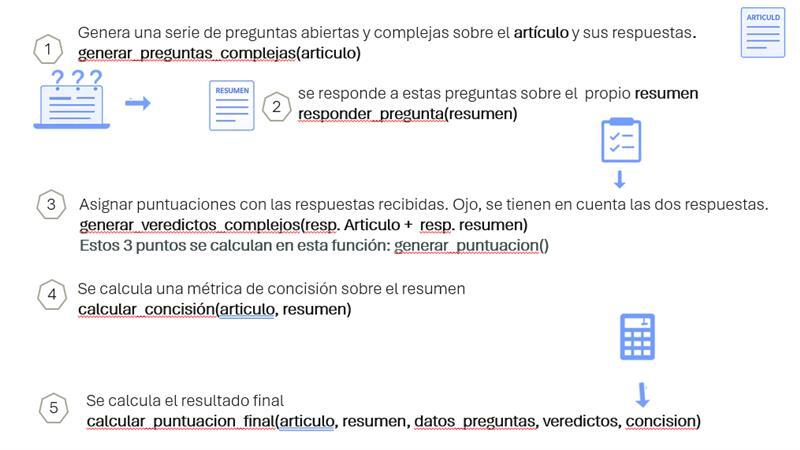

A continuación se muestran las funciones que se usarán para este ejemplo. 

*Función que genera preguntas complejas en base al documento original*

In [23]:
def generar_preguntas_complejas(texto, n=10):
    
    response_schema = {
    "type": "array",  
    "items": {       
        "type": "object",
        "properties": {
            "pregunta": {"type": "string"},
            "respuesta": {"type": "string"},
            "importancia": {"type": "number", "format": "integer"} # "format" es opcional pero útil
        },
        "required": ["pregunta", "respuesta", "importancia"]  
    },
    "description": "Una lista de elementos con sus detalles."
    }
    
    generation_config=GenerateContentConfig(
        max_output_tokens=8192,
        response_mime_type="application/json",
        response_schema=response_schema,
        thinking_config=ThinkingConfig(
            thinking_budget=0     # 0 apaga en; -1 automático
        )
    )
    
    prompt = f"""
    Eres un evaluador automático. A continuación se encuentra un texto.

    Texto:
    \"\"\"{texto}\"\"\"
    Basado en el siguiente texto, genera una lista de {n} preguntas que puedan responderse con la información del documento.
    Las preguntas deben estar relacionadas con los puntos principales del texto.
    Luego, proporciona una respuesta concisa (una frase corta) para cada pregunta, usando solo información que se encuentre en el texto.
    Responde de manera concisa; no es necesario que uses frases completas.
    Asegúrate de que las preguntas sean diferentes entre sí.
    Deben cubrir causas, impactos, políticas, ventajas/desventajas, etc.

    Finalmente, califica la importancia de cada pregunta en una escala del 1 (poco importante) al 5 (muy importante).
    Una pregunta importante está relacionada con puntos esenciales, y no conocerla implica no entender el texto principal.
    Una pregunta menos importante se refiere a detalles menores.

    Devuelve una lista JSON con objetos que tengan las claves: "pregunta", "respuesta" e "importancia".
    
    """

    responses = client.models.generate_content_stream(
        model=model, config=generation_config, contents=prompt
    )

    response_text = ""
    for response in responses:
        if response.text:
            response_text += response.text

    response_data = json.loads(response_text)
    try:
        return response_data  
    except Exception as e:
        print("⚠️ Error al interpretar las preguntas complejas:", response.text)
        return []

*Función para responder a una pregunta basada en un resumen*

In [24]:
def responder_pregunta(texto, pregunta):
    prompt = f"""
    Basado en el siguiente texto, responde a la pregunta con una frase corta o responde 'idk' si no hay información suficiente.

    Texto:
    \"\"\"{texto}\"\"\"

    Pregunta: {pregunta}
    """
    response = client.models.generate_content(
        model=model, contents=prompt
    )
    return response.text.strip().lower()

*Función que evalua las respuestas generadas en base al resumen y asigna una puntuación*

In [25]:
def generar_veredictos_complejos(respuestas):
    
    response_schema = {
    "type": "array",  
    "items": {       
        "type": "object",
        "properties": {
            "puntuacion": {"type": "number", "format": "float"},
            "razon": {"type": "string"},
        },
        "required": ["puntuacion", "razon"]  
    },
    "description": "Una lista de elementos con sus detalles."
    }

    generation_config=GenerateContentConfig(
        max_output_tokens=8192,
        response_mime_type="application/json",
        response_schema=response_schema,
        thinking_config=ThinkingConfig(
            thinking_budget=0     # 0 apaga en; -1 automático
        )
    )
    
    prompt = f"""
    Eres un evaluador experto. A continuación tienes una lista de objetos JSON, cada uno con dos campos:
    - 'respuesta_original' (respuesta correcta del texto original)
    - 'respuesta_resumen' (respuesta extraída del resumen)

    Tu tarea es:
    1. Evaluar si la respuesta del resumen es correcta en relación con la respuesta original.
    2. Asignar una puntuación de 0 a 5:
       - 5 = completamente correcta
       - 0 = incorrecta o 'idk'
    3. Justificar en 1 sola frase por qué diste esa puntuación.

    Devuelve solo una lista de JSON con "puntuacion" y "razon".

    Datos:
    {json.dumps(respuestas, ensure_ascii=False, indent=2)}
    """
    
    responses = client.models.generate_content_stream(
        model=model, config=generation_config, contents=prompt
    )
    
    response_text = ""
    for response in responses:
        if response.text:
            response_text += response.text
    
    response_data = json.loads(response_text)
    
    try:  
        return response_data
    except Exception as e:
        print("⚠️ Error al interpretar los veredictos:", response.text)
        return {"veredictos": []}

*Función para generar la puntuación de un resumen*

In [26]:
def generar_puntuacion(articulo, resumen):    
    # Generar preguntas desde el original
    datos_preguntas = generar_preguntas_complejas(articulo, n=10)

    # Obtener respuestas del resumen
    respuestas_a_evaluar = []
    for item in datos_preguntas:
        respuesta_resumen = responder_pregunta(resumen, item["pregunta"])
        respuestas_a_evaluar.append({
            "respuesta_original": item["respuesta"].lower(),
            "respuesta_resumen": respuesta_resumen.lower()
        })

    # Evaluar la calidad de las respuestas
    veredictos = generar_veredictos_complejos(respuestas_a_evaluar)

    return datos_preguntas, veredictos

Una vez se han definido las funciones para obtener la puntuación de las respuestas a cada pregunta formulada a partir del resumen, es necesario calcular una cifra final que represente la calidad global de este resumen. Para ello, primero evaluamos la concisión del resumen, asegurándonos de que sea más breve y directo que el texto original. Luego, calculamos una puntuación ponderada de las respuestas, teniendo en cuenta la importancia asignada a cada pregunta por Gemini.

Dado que la métrica de concisión se expresa en una escala de 0 a 1, mientras que la puntuación de las respuestas se encuentra en una escala de 0 a 5, es fundamental normalizar esta última para que ambas métricas estén en la misma escala.

Finalmente, la puntuación global del resumen se obtiene combinando ambas métricas (concisión y respuestas ponderadas) aplicando un peso específico a cada una, según la relevancia que se les asigne en el caso de uso particular.

*Función para calcular la métrica de concisión de un resumen*

In [27]:
def calcular_concisión(articulo, resumen):
    # Calculo de concisión
    length_ratio = len(resumen.split()) / len(articulo.split())
    concision = (1 - min(1, length_ratio))*100
    
    return concision

*Función para calcular el resultado final*

In [28]:
def calcular_puntuacion_final(articulo, resumen, datos_preguntas, veredictos, concision):

    # Calculo puntuacion ponderada en función de la importancia
    total_importancia = sum(p["importancia"] for p in datos_preguntas)

    # Extraer importancias y puntuaciones
    importancias = {f"pregunta_{i+1}": item["importancia"] for i, item in enumerate(datos_preguntas)}
    puntuaciones = {f"pregunta_{i+1}": item["puntuacion"] for i, item in enumerate(veredictos)}

    # Puntuacion ponderado
    ponderado = sum(puntuaciones[k] * importancias.get(k, 0) for k in puntuaciones)
    resultado_preguntas = ponderado / total_importancia

    # Normalizar la puntuacion ponderada y transformar a porcentaje
    resultado_normalizado = (resultado_preguntas / 5)*100
    
    # Calculo resultado final
    peso_preguntas = 0.5
    peso_concision = 0.5

    resultado_final = (peso_preguntas * resultado_normalizado + peso_concision * concision)
    
    return resultado_final

Aplicamos las funciones que se han creado para mostrar los resultados de los dos resúmenes. 

**Resultados para el resumen 1**

In [ ]:
# Mostrar resultados del resumen 1

print("Evaluación resumen 1:")
datos_preguntas, veredictos = generar_puntuacion(articulo, primer_resumen)

for i, v in enumerate(veredictos):
    print(f"\nPregunta {i+1}: Puntuación = {v['puntuacion']} - Razón: {v['razon']}")

concision = calcular_concisión(articulo, primer_resumen)
print(f"\nConcisión del resumen: {concision:.2f}%")

resultado_final = calcular_puntuacion_final(articulo, primer_resumen, datos_preguntas, veredictos, concision)
print(f"\nResultado final: {resultado_final:.2f}%")


**Resultados para el resumen 2**

In [19]:
# Mostrar resultados del resumen 2

print("Evaluación resumen 2:")
_, veredictos = generar_puntuacion(articulo, segundo_resumen)

for i, v in enumerate(veredictos):
    print(f"\nPregunta {i+1}: Puntuación = {v['puntuacion']} - Razón: {v['razon']}")

concision = calcular_concisión(articulo, segundo_resumen)
print(f"\nConcisión del resumen: {concision:.2f}%")

resultado_final = calcular_puntuacion_final(articulo, segundo_resumen, datos_preguntas, veredictos, concision)
print(f"\nResultado final: {resultado_final:.2f}%")

Evaluación resumen 2:

Pregunta 1: Puntuación = 5 - Razón: La respuesta del resumen es una reformulación concisa y precisa de la respuesta original.

Pregunta 2: Puntuación = 0 - Razón: La respuesta del resumen es demasiado vaga y pierde el detalle crucial de la comparación con la media europea.

Pregunta 3: Puntuación = 0 - Razón: La respuesta del resumen es completamente diferente y no coincide con la información de la respuesta original.

Pregunta 4: Puntuación = 5 - Razón: La respuesta del resumen es idéntica a la respuesta original, confirmando su corrección.

Pregunta 5: Puntuación = 5 - Razón: La respuesta del resumen es una versión ligeramente abreviada que conserva el significado completo de la respuesta original.

Pregunta 6: Puntuación = 5 - Razón: La respuesta del resumen es una representación numérica idéntica, solo con un formato diferente para el decimal.

Pregunta 7: Puntuación = 5 - Razón: La respuesta del resumen es una reformulación concisa que mantiene el significad

Podemos observar que, al pedirle a Gemini que genere resúmenes usando distintos prompts, la puntuación final obtenida también varía entre ambos resúmenes. Este resultado demuestra que las instrucciones incluidas en el prompt influyen tanto en el tipo de respuesta generada por Gemini como en su calidad.

In [25]:
df_final.head()

,Unnamed: 0,title,rating,review_text,location,hotel,label,resumen
0,3.0,SIN CALEFACCIÓN OPERATIVA Y CON FRÍO,2.0,Calefacción averiada o no operativa. Se coment...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,"La calefacción no funcionaba y, a pesar de rep..."
1,3.0,SIN CALEFACCIÓN OPERATIVA Y CON FRÍO,2.0,Calefacción averiada o no operativa. Se coment...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,El huésped sufrió frío debido a una calefacció...
2,3.0,SIN CALEFACCIÓN OPERATIVA Y CON FRÍO,2.0,Calefacción averiada o no operativa. Se coment...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,"La calefacción no funcionaba y, a pesar de rep..."
3,3.0,SIN CALEFACCIÓN OPERATIVA Y CON FRÍO,2.0,Calefacción averiada o no operativa. Se coment...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,"La calefacción no funcionaba y, a pesar de rep..."
4,4.0,Deja bastante que desear.,2.0,Este hotel ha bajado notoriamente su categoria...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,El huésped percibe un declive general en la ca...


## Extracción de categorías usando Gemini

De forma similar, podemos solicitar al modelo que extraiga las categorías principales de cada reseña. En esta etapa inicial, utilizamos un prompt básico para comprobar cómo Gemini interpreta el texto y qué tipo de categorías es capaz de extraer sin demasiada guía. Esto permite evaluar la capacidad del modelo para detectar temas relevantes de manera autónoma y sirve como punto de partida para iterar y mejorar el prompt. A partir de los resultados obtenidos, podemos ajustar las instrucciones para lograr una clasificación más precisa y coherente.

### Versión inicial

#### Procesamiento por lotes

En este caso, las reseñas se procesan en lotes, para mostrar una forma alternativa de enviar texto a Gemini.  Esta técnica es útil cuando se trabaja con grandes volúmenes de datos o se quieren evitar limitaciones en el tamaño de las solicitudes.

In [26]:
# Copiar DataFrame original ya que esto es solo un ejemplo
df_copy = df.copy()

In [27]:
def generar_categorias_general(df, lote_size = 50):
    categorias = []
    
    # Configurar parámetros del modelo
    generation_config = GenerateContentConfig(
        temperature=0.4,
        thinking_config=ThinkingConfig(
            thinking_budget=0     # 0 apaga en; -1 automático
        ),
        seed=34
    )
    
    for i in range(0, len(df), lote_size):
        bloque = df['review_text'].iloc[i:i+lote_size].tolist()
        texto = "\n".join([f"{idx+1}. {r}" for idx, r in enumerate(bloque)])

        prompt = f"""
        Eres un analista de texto experto en reseñas de hoteles. Tengo un conjunto de reseñas de hoteles escritas en español. Aquí están numeradas:

        {texto}

        Para cada reseña, identifica de 1 a 4 categorías clave que resuman de qué trata esa reseña.
        Devuélveme una línea por reseña, usando el mismo número de índice (1. 2. 3. ...) seguido por las categorías separadas por comas.
        """

        response = client.models.generate_content(
            model=model, config=generation_config, contents=prompt
        )

        # Extraer líneas tipo: 1. limpieza, ubicación, desayuno
        encontrados = re.findall(r'^\d+\.\s*(.*)', response.text, re.MULTILINE)

        # Si hay menos categorías de las esperadas, rellenar con vacíos
        if len(encontrados) < len(bloque):
            encontrados += [""] * (len(bloque) - len(encontrados))

        categorias.extend(encontrados)

    df['categorias'] = categorias
    return df

In [28]:
df_copy = generar_categorias_general(df_copy)
df_copy.head()

,Unnamed: 0,title,rating,review_text,location,hotel,label,categorias
0,3.0,SIN CALEFACCIÓN OPERATIVA Y CON FRÍO,2.0,Calefacción averiada o no operativa. Se coment...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,"Calefacción, Servicio al cliente, Categoría de..."
1,4.0,Deja bastante que desear.,2.0,Este hotel ha bajado notoriamente su categoria...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,"Categoría del hotel, Habitaciones, Servicio de..."
2,24.0,Normalito,3.0,Normalito para ser un 4 estrellas. El trato bi...,Seville_Province_of_Seville_Andalucia,Ayre_Hotel_Sevilla,3.0,"Categoría del hotel, Servicio al cliente, Prot..."
3,39.0,Por una noche,1.0,Habitacion amplia pero algo sucia y mui viejo ...,Seville_Province_of_Seville_Andalucia,Hotel_Virgen_de_los_Reyes,0.0,"Habitaciones, Limpieza, Precio, Comodidad de c..."
4,40.0,NI HIGIENE NI MEDIDAS,1.0,Habitacion con sabanas manchadas y con pelos N...,Seville_Province_of_Seville_Andalucia,Hilton_Garden_Inn_Sevilla,0.0,"Limpieza, Protocolo Covid, Habitaciones, Ameni..."


In [29]:
lista_categorias_general = []

for fila in df_copy['categorias']:
    categorias = [t.strip() for t in fila.split(',')]  # separa y limpia espacios
    lista_categorias_general.extend(categorias)

# Convertir la lista a un set para eliminar duplicados
categorias_unicas_general = set(lista_categorias_general)
print('Número de categorías únicas: ', len(categorias_unicas_general))

# Convertir el set a una lista para poder hacer slicing
list_categorias_unicas_general = list(categorias_unicas_general)

print('Primeros ejemplos de categorías únicas: ', list_categorias_unicas_general[:30])

Número de categorías únicas:  241
Primeros ejemplos de categorías únicas:  ['Comida/Bebida', 'Climatización', 'Decepcionante', 'Garaje', 'Recepción', 'Cancelación de reserva', 'Diseño', 'Retraso', 'Mobiliario', 'Tecnología', 'Atención del personal', 'Luz', 'Limpieza', 'Precios elevados', 'Sucio', 'Habitación cutre', 'Accesibilidad', 'Falta de sueño', 'Iluminación', 'Insonorización', 'Reserva', 'Medidas COVID', 'Falta de comunicación', 'Detalles', 'Playa', 'Lujo', 'Ubicación', 'Publicidad engañosa', 'Vistas', 'Satisfacción general']


Como podemos observar en los resultados obtenidos, las categorías generadas no cumplen con nuestras expectativas, ya que son muy específicos o presentan frases demasiado largas. De hecho, Gemini produce mas de 100 categorías diferentes, cuando en realidad necesitamos obtener categorías más generales que se repitan entre las distintas reseñas para facilitar el análisis.

Este problema se debe principalmente al contenido del prompt utilizado: es muy general y solo contiene una instrucción básica, sin detalles ni ejemplos que guíen al modelo hacia el tipo de respuesta deseada. Esto resalta la importancia fundamental de diseñar prompts bien estructurados, detallados y explícitos. Un buen prompt debe incluir contexto, objetivos claros y ejemplos de formato o contenido.

El proceso de redactar un buen prompt es manual y requiere observación cuidadosa. Consiste en analizar las respuestas generadas por Gemini, identificar áreas de mejora y ajustar el prompt progresivamente. Esto puede incluir añadir instrucciones más específicas, aclarar el formato deseado o proporcionar ejemplos concretos.

### Versión iterada

En esta segunda parte, creamos un prompt iterado y mejorado, que permite a Gemini extraer categorías de manera más alineada con nuestras necesidades. 
Además, es importante destacar que en la versión anterior se procesaron las reseñas en lotes. Pero, cuando el tamaño del conjunto de datos lo permite, es preferible enviar todo el texto a Gemini en un solo bloque. De esta forma, el modelo puede analizar el contexto completo sin fragmentarlo, lo que suele mejorar la coherencia y calidad de los resultados. También reduce la complejidad del código y disminuye el número de llamadas al modelo, lo que puede traducirse en un ahorro de cost y tiempo. Sin embargo, esta opción solo es viable si el total de tokens está dentro de los límites que Gemini puede manejar sin problemas.

In [30]:
def generar_categorias_todo(df):
    categorias = []

    # Configurar parámetros del modelo
    generation_config = GenerateContentConfig(
        temperature=0.4,
        seed=34,
        thinking_config=ThinkingConfig(
            thinking_budget=0     # 0 apaga en; -1 automático
        )
    )
    
    # Convertir todas las reseñas a texto numerado
    texto = "\n".join([f"{idx+1}. {r}" for idx, r in enumerate(df['review_text'].tolist())])

    prompt = f"""
    Eres un analista de texto experto en reseñas de hoteles. Tengo un conjunto de reseñas de hoteles escritas en español. Lee con atención todas las reseñas y solo luego efectua la tarea que te pido.
    Aquí están numeradas:

    {texto}

    Para cada reseña proporcionada:
    Identifica de 1 a 4 categorías clave y temas principales que resuman de qué trata esa reseña. Cada categorías debe contener 1, 2 o 3 palabras.
    Identifica solo categorías generales relacionadas con funcionalidades y servicios de hoteles. Las categorías extraidas no deben ser específicos. 
    No incluyas palabras entre paréntesis. Devuelve los nombres de todas categorías en minúscula y en forma singular. 
    No incluyas caracteres especiales como guiones (-), barras (|) o diagonales (/).
    Mantén el orden y devuelve las categorías como una lista numerada, en el mismo formato.
    Usa unicamente la informacion proporcionada.
    
    Ejemplos de formato esperado:
    1. limpieza
    2. atención al cliente, ubicación
    3. ruido, comodidad, desayuno
    4. atención al cliente, comida, instalaciones, ubicación

    No agregues texto adicional, explicaciones ni encabezados. Solo la lista numerada con las categorías, una línea por reseña.
    """

    response = client.models.generate_content(
        model=model, config=generation_config, contents=prompt
    )

    # Extraer líneas tipo: 1. limpieza, ubicación
    matches = re.findall(r'^\d+\.\s*(.+)', response.text, re.MULTILINE)

    categorias = [m.strip() for m in matches]

    # Rellenar si faltan resultados
    while len(categorias) < len(df):
        categorias.append("")

    df['categorias'] = categorias

    return df, response

In [31]:
df_copy = df.copy()
df_copy, response = generar_categorias_todo(df_copy)
df_copy.head()

,Unnamed: 0,title,rating,review_text,location,hotel,label,categorias
0,3.0,SIN CALEFACCIÓN OPERATIVA Y CON FRÍO,2.0,Calefacción averiada o no operativa. Se coment...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,"calefacción, atención al cliente"
1,4.0,Deja bastante que desear.,2.0,Este hotel ha bajado notoriamente su categoria...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,"instalaciones, servicio, limpieza, comodidad"
2,24.0,Normalito,3.0,Normalito para ser un 4 estrellas. El trato bi...,Seville_Province_of_Seville_Andalucia,Ayre_Hotel_Sevilla,3.0,"servicio, instalaciones, ubicación"
3,39.0,Por una noche,1.0,Habitacion amplia pero algo sucia y mui viejo ...,Seville_Province_of_Seville_Andalucia,Hotel_Virgen_de_los_Reyes,0.0,"limpieza, comodidad, instalaciones, precio"
4,40.0,NI HIGIENE NI MEDIDAS,1.0,Habitacion con sabanas manchadas y con pelos N...,Seville_Province_of_Seville_Andalucia,Hilton_Garden_Inn_Sevilla,0.0,"limpieza, instalaciones, covid"


In [32]:
lista_categorias = []

for fila in df_copy['categorias']:
    categorias = [t.strip() for t in fila.split(',')]  # separa y limpia espacios
    lista_categorias.extend(categorias)
      
# Convertir la lista a un set para eliminar duplicados
categorias_unicas_set = set(lista_categorias)

# Convertir el set a una lista para poder hacer slicing
categorias_unicas = [t for t in categorias_unicas_set if t]

print('Número de categorías únicas: ', len(categorias_unicas))
print('Categorías: ', categorias_unicas)

Número de categorías únicas:  16
Categorías:  ['ruido', 'desayuno', 'limpieza', 'instalaciones', 'transporte', 'ambiente', 'seguridad', 'precio', 'ubicación', 'covid', 'piscina', 'atención al cliente', 'comida', 'servicio', 'calefacción', 'comodidad']


## Análisis de las categorías extraídas

### Frecuencia de categorías

El análisis de las categorías extraídas puede realizarse desde diferentes enfoques, y en esta sección exploraremos algunos de los más relevantes.

Una primera estrategia consiste en identificar las categorías que se repiten con mayor frecuencia en las reseñas, con el objetivo de determinar cuáles representan las categorías predominantes en las opiniones de los usuarios.

In [33]:
def contar_categorias(df, categorias_unicas):
    count = []

    for categoria in categorias_unicas:
        # Contar cuántas filas contienen la categoría
        n = df['categorias'].apply(lambda x: categoria in [t.strip() for t in x.split(',')] if isinstance(x, str) else False).sum()
        count.append((categoria, n))

    # Crear un DataFrame con los resultados
    df_categorias = pd.DataFrame(count, columns=['categoría', 'número_reseñas'])

    # Ordenar por número de reseñas en orden descendente
    df_categorias = df_categorias.sort_values(by='número_reseñas', ascending=False).reset_index(drop=True)

    return df_categorias

In [34]:
df_categorias = contar_categorias(df_copy, categorias_unicas)
df_categorias.head()

,categoría,número_reseñas
0,instalaciones,389
1,atención al cliente,333
2,ubicación,281
3,limpieza,214
4,servicio,164


In [35]:
def generar_wordcloud_categorias(df_categorias, max_categorias):
    # Seleccionar las 30 categorías más frecuentes
    top_df = df_categorias.nlargest(max_categorias, 'número_reseñas')

    # Convertir a diccionario: {'categoría': frecuencia}
    frecuencia = dict(zip(top_df['categoría'], top_df['número_reseñas']))

    # Crear la nube de palabras ponderada por frecuencia
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='plasma',
        max_words=max_categorias
    ).generate_from_frequencies(frecuencia)


    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nube de palabras (top {max_categorias} categorías más comunes)", fontsize=16)
    plt.show()

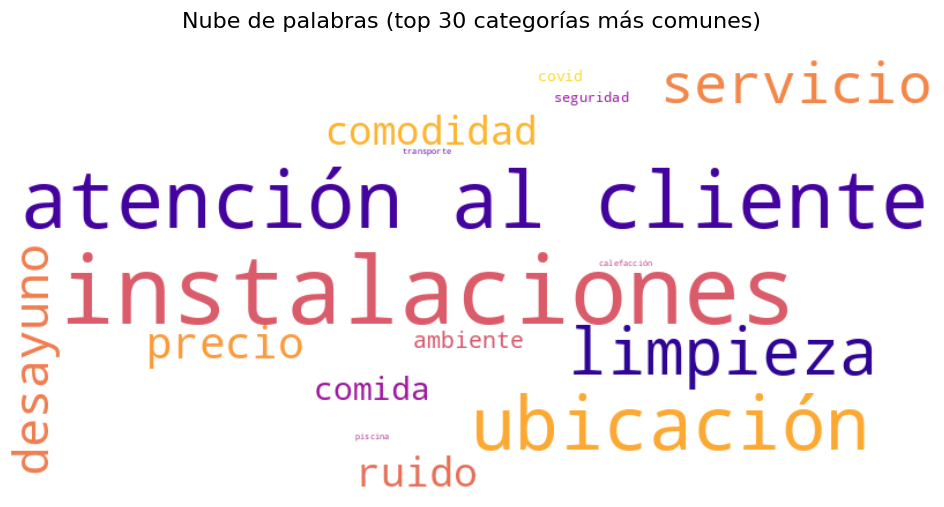

In [36]:
generar_wordcloud_categorias(df_categorias, max_categorias=30)

## Evaluación de categorías

La validación de sistemas con modelos de lenguaje se basa en métricas que evalúan con precisión el rendimiento del modelo. Una de las métricas principales utilizadas es el **recall**, que representa la proporción de elementos positivos correctamente identificados por el modelo sobre el total real de elementos positivos en el conjunto de datos. Esta métrica es especialmente útil cuando el objetivo es minimizar los falsos negativos. 

**Recall = Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos)**. 

Junto al recall, se suele utilizar la **precision**, que mide la proporción de predicciones correctas entre todos los elementos que el modelo ha clasificado como positivos. Mientras que el recall evalúa la cobertura del modelo, la precision se enfoca en su exactitud. 

**Precision = Verdaderos Positivos / (Verdaderos Positivos + Falsos Positivos)**. 

Para obtener una medida balanceada entre ambas métricas, se utiliza el **F1-score**, que es la media armónica entre precision y recall y proporciona una única cifra que resume el equilibrio entre ambas:

**F1-score = 2 × (Precision × Recall) / (Precision + Recall)**. 

Estas métricas permiten evaluar si una nueva versión del prompt o un ajuste en la configuración del modelo mejora la calidad de la clasificación en comparación con una versión anterior. Además de estas métricas, se puede emplear la **matriz de confusión**, una herramienta que organiza las predicciones del modelo en cuatro categorías: verdaderos positivos (VP), verdaderos negativos (VN), falsos positivos (FP) y falsos negativos (FN). Esta matriz facilita una visualización clara de los aciertos y errores del modelo, permitiendo identificar patrones de fallo específicos. En conjunto, estas métricas no solo cuantifican el rendimiento general del sistema, sino que también guían el proceso iterativo de optimización de prompts y mejora del modelo.


En resumen: 

* Precision: mide la proporción de predicciones correctas entre todas las predicciones positivas.

* Recall: mide la proporción de predicciones correctas entre todos los casos positivos reales.

* F1-score: es la media armónica entre precision y recall.

En este caso, utilizamos tres métricas para evaluar la calidad de las categorías extraídas, comparando las categorías de referencia, que en este contexto corresponden a las categorías principales, can los categorías obtenidas en las tres primeras líneas, con el objetivo de ilustrar cómo funcionaría el proceso.

En este código, se utiliza la clase SequenceMatcher del módulo difflib para medir la similitud entre dos cadenas de texto. Esta herramienta compara dos textos y devuelve un valor numérico entre 0 y 1, que representa su similitud. Un valor de 1 indica que las cadenas son exactamente iguales, mientras que un valor cercano a 0 sugiere que comparten muy pocos elementos en común. Por ejemplo, las cadenas "Ubicación" y "Ubicacion" tienen una similitud muy alta (alrededor de 0.95), mientras que "Limpieza" y "Limpio" también tienen cierta similitud (alrededor de 0.57), aunque no son idénticas.

El parámetro threshold (o umbral) es fundamental en este proceso, ya que establece el punto de corte a partir del cual se considera que dos cadenas son lo suficientemente similares como para ser tratadas como una coincidencia. En la función similar(a, b, threshold), se devuelve True si la similitud calculada por SequenceMatcher es mayor o igual al umbral definido. Por ejemplo, si el umbral es 0.4, entonces cualquier par de textos cuya similitud sea del 40% o más será considerado una coincidencia.

In [37]:
# Esta función devuelve True si la similitud es mayor o igual al threshold
def similar(a, b, threshold):
    return SequenceMatcher(None, a, b).ratio() >= threshold

# Esta función compara cada tema extraído con todos los temas de referencia
def match_categorias(extracted, reference, threshold):
    matched = []
    for e in extracted:
        for r in reference:
            if similar(e, r, threshold):
                matched.append((e, r))
                break
    return matched

def evaluate_categorias(extracted_categorias, reference_categorias, threshold):
    
    matched = match_categorias(extracted_categorias, reference_categorias, threshold)
    matched_extracted = set(e for e, _ in matched)
    matched_reference = set(r for _, r in matched)

    # Temas en comun
    number_common = len(matched_extracted)
    
    # Temas generados
    number_extracted = len(extracted_categorias)
    
    # Temas de referencia
    number_reference = len(reference_categorias)
    
    # Precision: de los extraídos, ¿cuántos fueron correctos?
    precision = number_common / number_extracted

    # Recall: de los correctos, ¿cuántos se extrajeron?
    recall = number_common / number_reference
    
    # F1- score
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print("Evaluación de categorías:")
    print(f"Referencias: {reference_categorias}")
    print(f"Extraídos:   {extracted_categorias}")
    print(f"categorías Coincidentes (≥{threshold}): {[e for e, _ in matched]}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")
    print(f"F1-score:  {f1:.2f}")

Ejemplo de uso: Supongamos que contamos con un conjunto de categorías previamente etiquetadas que deberían aparecer en un resumen de un texto o reseña. Este ejemplo sirve como demostración (dummy) para ilustrar cómo se podría evaluar automáticamente la calidad de la extracción de categorías de un modelo o algoritmo. En este caso, las categorías en `reference` representan las etiquetas correctas, mientras que las categorías en `extracted` son las obtenidas por el modelo.

In [38]:
reference = [
    "Ubicación", 
    "Atención al cliente", 
    "Limpieza",  
    "Habitación",
    "Desayuno",   
    "Instalaciones", 
    "Ruido"
]

extracted = [
    "Calefacción", 
    "Atención al cliente",
    "Servicio de habitación", 
    "Baño", 
    "Limpieza",
    "Protocolo covid", 
    "Ubicación",
    "Cama", 
    "Precio"
]

evaluate_categorias(extracted, reference, threshold=0.4)

Evaluación de categorías:
Referencias: ['Ubicación', 'Atención al cliente', 'Limpieza', 'Habitación', 'Desayuno', 'Instalaciones', 'Ruido']
Extraídos:   ['Calefacción', 'Atención al cliente', 'Servicio de habitación', 'Baño', 'Limpieza', 'Protocolo covid', 'Ubicación', 'Cama', 'Precio']
categorías Coincidentes (≥0.4): ['Calefacción', 'Atención al cliente', 'Servicio de habitación', 'Limpieza', 'Ubicación']
Precision: 0.56
Recall:    0.71
F1-score:  0.63


## Clasificación temática con categorías predefinidas

En los apartados anteriores, se han generado categorías temáticas automáticamente mediante un prompt, solicitando a Gemini que propusiera grupos generales a partir del contenido de las reseñas. Esta técnica resulta útil cuando no se dispone de una clasificación previa, ya que permite identificar patrones comunes y organizar el texto de forma estructurada. Una vez obtenidas, estas categorías pueden evaluarse observando si las reseñas se agrupan de manera coherente y representativa del contenido. Si la distribución es lógica, se puede considerar que las categorías son adecuadas para el análisis.
Tras realizar un análisis exhaustivo de las categorías extraídas, se ha optado por definir manualmente las siguientes categorías temáticas:

- Ubicación  
- Atención al cliente  
- Limpieza  
- Habitación  
- Desayuno    
- Instalaciones  
- Ruido   
- Otros

A partir de esta clasificación, se solicita a Gemini que asigne cada reseña a una de estas ocho categorías. Este enfoque permite organizar el contenido de forma más precisa, facilitando tanto el análisis como la interpretación de las opiniones. La clasificación automática agiliza la detección de patrones y tendencias en grandes volúmenes de texto, sin necesidad de revisar cada reseña individualmente. Además, esta segmentación temática permite enfocar acciones concretas en función de los aspectos más relevantes identificados en las valoraciones de los usuarios.


In [39]:
def clasificar_categorias(df):
    
    # Configurar parámetros del modelo
    generation_config = GenerateContentConfig(
        temperature=0.4,
        seed=34,
        thinking_config=ThinkingConfig(
            thinking_budget=0     # 0 apaga en; -1 automático
        )
    )

    # Convertir todas las reseñas a un solo bloque de texto numerado
    texto = "\n".join([f"{idx + 1}. {r}" for idx, r in enumerate(df['review_text'].tolist())])

    prompt = f"""
    Eres un analista de texto experto en reseñas de hoteles. Tengo un conjunto de reseñas escritas en español. Aquí están numeradas:

    {texto}

    Clasifica cada reseña en función de las siguientes categorías a la que mejor se le ajuste:

    1. Ubicación  
    2. Atención al cliente  
    3. Limpieza  
    4. Habitación  
    5. Desayuno    
    6. Instalaciones  
    7. Ruido   
    8. Otros

    Si no puedes identificar la categoría, clasifica como "Otros".

    Devuelve únicamente una lista numerada del tipo:
    1. Limpieza  
    2. Habitación  
    3. Otros

    No agregues texto adicional, encabezados ni explicaciones.
    """

    # Llamada a Gemini
    response = client.models.generate_content(
        model=model, config=generation_config, contents=prompt
    )

    # Extraer líneas
    lineas = re.findall(r'^\d+\.\s*(.+)', response.text, re.MULTILINE)
    
    # Filtrar líneas vacías por si acaso
    lineas = [linea.strip() for linea in lineas if linea.strip()]

    # Ajustar tamaño: si hay más líneas, cortamos; si hay menos, rellenamos con "Otros"
    if len(lineas) > len(df):
        lineas = lineas[:len(df)]
    elif len(lineas) < len(df):
        lineas += ["Otros"] * (len(df) - len(lineas))


    df['categoria'] = lineas
    return df


In [40]:
df_copy = df.copy()
df_copy = clasificar_categorias(df_copy)
df_copy.head()

,Unnamed: 0,title,rating,review_text,location,hotel,label,categoria
0,3.0,SIN CALEFACCIÓN OPERATIVA Y CON FRÍO,2.0,Calefacción averiada o no operativa. Se coment...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,Habitación
1,4.0,Deja bastante que desear.,2.0,Este hotel ha bajado notoriamente su categoria...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,Habitación
2,24.0,Normalito,3.0,Normalito para ser un 4 estrellas. El trato bi...,Seville_Province_of_Seville_Andalucia,Ayre_Hotel_Sevilla,3.0,Otros
3,39.0,Por una noche,1.0,Habitacion amplia pero algo sucia y mui viejo ...,Seville_Province_of_Seville_Andalucia,Hotel_Virgen_de_los_Reyes,0.0,Habitación
4,40.0,NI HIGIENE NI MEDIDAS,1.0,Habitacion con sabanas manchadas y con pelos N...,Seville_Province_of_Seville_Andalucia,Hilton_Garden_Inn_Sevilla,0.0,Habitación


In [41]:
def extraer_satisfaccion_por_lotes(df, lote_size=10):
    satisfaccion = []
    df = df.copy()
      
    # Configurar parámetros del modelo
    generation_config = GenerateContentConfig(
        temperature=0.4,
        tools=[]
    )
    

    for i in range(0, len(df), lote_size):
        bloque = df['review_text'].iloc[i:i+lote_size].tolist()
        texto = "\n".join([f"{idx+1}. {r}" for idx, r in enumerate(bloque)])

        prompt = f"""
        Eres un analista de texto experto en reseñas de clientes. Tengo un DataFrame con reseñas de hoteles en español numeradas así:

        {texto}

        Para cada reseña identifica la satisfaccion correspondiente (Positivo, Negativo o Neutral).
        Devuélveme solo una palabra por reseña en una lista numerada, sin texto extra.
        
        Ejemplos:
        1. La habitación estaba limpia y el personal fue muy amable.  
        2. El baño tenía moho y la cama era incómoda.  
        3. La ubicación era buena, pero el servicio fue regular.

        Salida esperada:
        1. Positivo  
        2. Negativo  
        3. Neutral
        Usa unicamente la informacion proporcionada en el dataframe. No hagas consultas en internet.
        """

        response = client.models.generate_content(
            model=model, config=generation_config, contents=prompt
        )

        # Extraer satisfaccion con regex
        encontrados = re.findall(r'^\d+\.\s*(.*)', response.text.strip(), re.MULTILINE)

        # Rellenar si falta satisfaccion
        if len(encontrados) < len(bloque):
            encontrados += [""] * (len(bloque) - len(encontrados))

        satisfaccion.extend(encontrados)

    df['satisfaccion'] = satisfaccion
    return df, response, prompt

In [42]:
df_copy = df.copy()
df_copy, response, prompt = extraer_satisfaccion_por_lotes(df_copy[:30])
df_copy.head()

,Unnamed: 0,title,rating,review_text,location,hotel,label,satisfaccion
0,3.0,SIN CALEFACCIÓN OPERATIVA Y CON FRÍO,2.0,Calefacción averiada o no operativa. Se coment...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,Negativo
1,4.0,Deja bastante que desear.,2.0,Este hotel ha bajado notoriamente su categoria...,Seville_Province_of_Seville_Andalucia,Melia_Sevilla,0.0,Negativo
2,24.0,Normalito,3.0,Normalito para ser un 4 estrellas. El trato bi...,Seville_Province_of_Seville_Andalucia,Ayre_Hotel_Sevilla,3.0,Neutral
3,39.0,Por una noche,1.0,Habitacion amplia pero algo sucia y mui viejo ...,Seville_Province_of_Seville_Andalucia,Hotel_Virgen_de_los_Reyes,0.0,Negativo
4,40.0,NI HIGIENE NI MEDIDAS,1.0,Habitacion con sabanas manchadas y con pelos N...,Seville_Province_of_Seville_Andalucia,Hilton_Garden_Inn_Sevilla,0.0,Negativo


## Extracción de satisfaccion usando Gemini

De forma similar a los ejemplos anteriores, podemos pedirle a Gemini, mediante un prompt claro y detallado, que extraiga la satisfaccion de cada reseña. Al igual que antes, incluimos ejemplos en el prompt para guiar mejor al modelo y obtener respuestas más precisas y consistentes. En este caso las reseñas se procesan en lotes de 10 y por tiempos de ejecución, vamos a realizarlo para las primeras 30 filas del dataframe.

In [35]:
def extraer_satisfaccion_por_lotes(df, lote_size=10):
    satisfaccion = []
    df = df.copy()
      
    # Configurar parámetros del modelo
    generation_config = GenerateContentConfig(
        temperature=0.4,
        tools=[]
    )
    

    for i in range(0, len(df), lote_size):
        bloque = df['review_text'].iloc[i:i+lote_size].tolist()
        texto = "\n".join([f"{idx+1}. {r}" for idx, r in enumerate(bloque)])

        prompt = f"""
        Eres un analista de texto experto en reseñas de clientes. Tengo un DataFrame con reseñas de hoteles en español numeradas así:

        {texto}

        Para cada reseña identifica la satisfaccion correspondiente (Positivo, Negativo o Neutral).
        Devuélveme solo una palabra por reseña en una lista numerada, sin texto extra.
        
        Ejemplos:
        1. La habitación estaba limpia y el personal fue muy amable.  
        2. El baño tenía moho y la cama era incómoda.  
        3. La ubicación era buena, pero el servicio fue regular.

        Salida esperada:
        1. Positivo  
        2. Negativo  
        3. Neutral
        Usa unicamente la informacion proporcionada en el dataframe. No hagas consultas en internet.
        """

        response = client.models.generate_content(
            model=model, config=generation_config, contents=prompt
        )

        # Extraer satisfaccion con regex
        encontrados = re.findall(r'^\d+\.\s*(.*)', response.text.strip(), re.MULTILINE)

        # Rellenar si falta satisfaccion
        if len(encontrados) < len(bloque):
            encontrados += [""] * (len(bloque) - len(encontrados))

        satisfaccion.extend(encontrados)

    df['satisfaccion'] = satisfaccion
    return df, response, prompt

In [36]:
df_copy = df.copy()
df_copy, response, prompt = extraer_satisfaccion_por_lotes(df_copy[:30])
df_copy.head()

,Unnamed: 0,title,rating,review_text,location,hotel,label,satisfaccion
0,0,Excelente y personal amable,5,Un hotel muy bueno. El personal fue muy amabl...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1,Positivo
1,1,Céntrico,4,"Muy buen hotel al nivel de lo esperado, habita...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1,Positivo
2,2,Hotel excepcional,5,Magnífico hotel. La verdad es que todo perfect...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1,Positivo
3,3,WOW!!,5,"Hotel hermoso, buen diseño, original, limpio. ...",Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1,Positivo
4,4,Magnifico,5,Magnífica ubicación en pleno centro de Sevilla...,Seville_Province_of_Seville_Andalucia,H10_Casa_de_la_Plata,1,Positivo


## Evaluación de Satisfacción

En esta sección presentamos una forma de evaluar la precisión de la extracción de satisfacción realizada por Gemini, analizando las primeras 20 reseñas. Para ello, asignamos manualmente un valor de satisfacción real a cada reseña y lo comparamos con el valor generado automáticamente por el modelo. Primero calcularemos la precisión, el recall y el f1-score manualmente como hemos hecho anteriormente. Posteriormente utilizamos dos herramientas principales: la **matriz de confusión**, que muestra de forma visual cuántas veces el modelo acierta o se equivoca en cada categoría de satisfacción, y el **informe de clasificación**, que ofrece medidas más detalladas como la precisión, el recall y el F1-score para cada clase, proporcionando así una visión más completa del rendimiento del modelo. Además, el informe de clasificación incluye la métrica de accuracy, que indica el porcentaje total de predicciones correctas realizadas por el modelo.

### Precision, recall y f1-score

In [ ]:
y_pred = df_satisfaccion['satisfaccion']
y_true = df_satisfaccion['satisfaccion_real']

precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

print('Precision: ', round(precision,2))
print('Recall: ', round(recall,2))
print('F1: ', round(f1,2))

### Matriz de confusión e informe de clasificación

In [ ]:
# Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=df_satisfaccion['satisfaccion_real'].unique())

# Mostrar matriz de confusión con etiquetas
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=df_satisfaccion['satisfaccion_real'].unique())
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión: Satisfaccion Predicha vs Reales")
plt.show()

# Generar informe de clasificación
reporte = classification_report(y_true, y_pred,  zero_division=0, output_dict=False)
print(reporte)